In [1]:
from mpi4py import MPI
import dolfinx
import dolfinx_mpc
import numpy as np
import ufl
from petsc4py.PETSc import ScalarType
comm = MPI.COMM_WORLD

### Create mesh and function spaces
domain = dolfinx.mesh.create_unit_interval(comm, 15)
element1 = ufl.FiniteElement("Lagrange", domain.ufl_cell(), 1)
V = dolfinx.fem.FunctionSpace(domain, ufl.MixedElement([element1, element1]))
V0c, submap = V.sub(0).collapse()
V1 = V.sub(1)

### Create test and test functions
v, r = ufl.TestFunctions(V)
uh = dolfinx.fem.Function(V)
u, m = ufl.TrialFunctions(V)#

### Mark boundaries
def right_boundary(x): return np.isclose(x[0], 1.0)
def left_boundary(x): return np.isclose(x[0], 0.0)
def domain_nodes(x): return ~np.logical_or(left_boundary(x), right_boundary(x))

node_left = dolfinx.mesh.locate_entities_boundary(domain, 0, left_boundary)
node_right = dolfinx.mesh.locate_entities_boundary(domain, 0, right_boundary)
node_middle = dolfinx.mesh.locate_entities_boundary(domain, 0, domain_nodes)
tags = {"left": 2, "right": 3, "middle": 1}
marker_left = np.full_like(node_left, tags["left"])
marker_right = np.full_like(node_right, tags["right"])
marker_middle = np.full_like(node_middle, tags["middle"])
nodes = np.concatenate((node_left, node_right, node_middle))
markers = np.concatenate((marker_left, marker_right, marker_middle))
idx = np.argsort(nodes)

ft = dolfinx.mesh.meshtags(domain, 0, nodes[idx], markers[idx])

### Create Dirichlet bcs
right_facets = dolfinx.fem.locate_dofs_geometrical((V.sub(0), V0c), right_boundary)
bc_r = dolfinx.fem.dirichletbc(ScalarType(1.5), right_facets[0], V.sub(0))

### MultiPointConstraint
mpc = dolfinx_mpc.MultiPointConstraint(V)

# Find the master dof (x = 0.0) and owning process
nodes = dolfinx.mesh.locate_entities_boundary(domain, 0, lambda x: np.isclose(x[0], 0.0))
master_dof = dolfinx.fem.locate_dofs_topological(V1, 0, nodes, remote=False)
master_owner = np.full_like(master_dof, comm.rank)
master_dof = np.concatenate(comm.allgather(master_dof), dtype=np.int64)
master_owner = np.concatenate(comm.allgather(master_owner), dtype=np.int32)

# Check for correct number of master dofs (should be 1)
if master_dof.size != 1:
    raise RuntimeError(f"Expected to find 1 master dof; found {master_dof.size}")
else:
    print(f"[{comm.rank}]: master_dof = {master_dof}")
    print(f"[{comm.rank}]: master_owner = {master_owner}")

# Find the slave nodes
nodes = dolfinx.mesh.locate_entities(domain, 0, lambda x: ~np.isclose(x[0], 0.0))
slave_dof = dolfinx.fem.locate_dofs_topological(V1, 0, nodes, remote=False)
print(f"[{comm.rank}]: slave_dof = {slave_dof}")

# Create arrays for use by mpc.add_constraint
masters = np.broadcast_to(master_dof, slave_dof.shape)
owners = np.broadcast_to(master_owner, slave_dof.shape)
coeffs = np.ones_like(masters, dtype=ScalarType)
offsets = np.arange(masters.size + 1, dtype=np.int32)

# Create constraint and finalize mpc
mpc.add_constraint(V, slave_dof, masters, coeffs, owners, offsets)
mpc.finalize()

### Create variational form and solve
C0 = dolfinx.fem.Constant(domain, ScalarType(1))
f = dolfinx.fem.Constant(domain, ScalarType(1))

# a = ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx + m*v*ufl.dx + u * r * ufl.dx
n = ufl.FacetNormal(domain)
ds = ufl.Measure("ds", domain, subdomain_data=ft)
a = (
    ufl.inner(ufl.grad(u), ufl.grad(v))*ufl.dx
    + ufl.inner(m, v)*ufl.dx
    + ufl.inner(u, r)*ufl.dx
    - ufl.inner(ufl.grad(u), n * v)*ds(tags["left"])
)
L = ufl.inner(f, v)*ufl.dx  +  ufl.inner(C0, r)*ufl.dx
problem = dolfinx_mpc.LinearProblem(
    a, L, mpc, bcs=[bc_r],
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    }
)
uh = problem.solve()
print(uh.x.array)

ModuleNotFoundError: No module named 'dolfinx_mpc'

In [ ]:
from pathlib import Path

from mpi4py import MPI
from petsc4py.PETSc import ScalarType  # type: ignore

import numpy as np

import ufl
from dolfinx import fem, io, mesh, plot
from dolfinx.fem.petsc import LinearProblem

In [ ]:
msh = mesh.create_interval(
    comm=MPI.COMM_WORLD,
    points=(0, 2.0),
    nx=36
)
V = fem.functionspace(msh, ("Lagrange", 1))

facets = mesh.locate_entities_boundary(
    msh,
    dim=(msh.topology.dim - 1),
    marker=lambda x: np.isclose(x[0], 0.0) | np.isclose(x[0], 2.0),
)
dofs = fem.locate_dofs_geometrical(V=V, entity_dim=1, entities=facets)
bc = fem.dirichletbc(value=ScalarType(0), dofs=dofs, V=V)

RuntimeError: Entity-to-cell connectivity has not been computed. Missing dims 1->1

In [ ]:
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
x = ufl.SpatialCoordinate(msh)
f = 10 * ufl.exp(-((x[0] - 0.5) ** 2 + (x[1] - 0.5) ** 2) / 0.02)
g = ufl.sin(5 * x[0])
a = ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx
L = ufl.inner(f, v) * ufl.dx + ufl.inner(g, v) * ufl.ds

problem = LinearProblem(
    a,
    L,
    bcs=[bc],
    petsc_options_prefix="demo_poisson_",
    petsc_options={"ksp_type": "preonly", "pc_type": "lu", "ksp_error_if_not_converged": True},
)
uh = problem.solve()
assert isinstance(uh, fem.Function)

In [ ]:
out_folder = Path("out_poisson")
out_folder.mkdir(parents=True, exist_ok=True)
with io.XDMFFile(msh.comm, out_folder / "poisson.xdmf", "w") as file:
    file.write_mesh(msh)
    file.write_function(uh)

/tmp/ipykernel_7664/1961326858.py:14: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


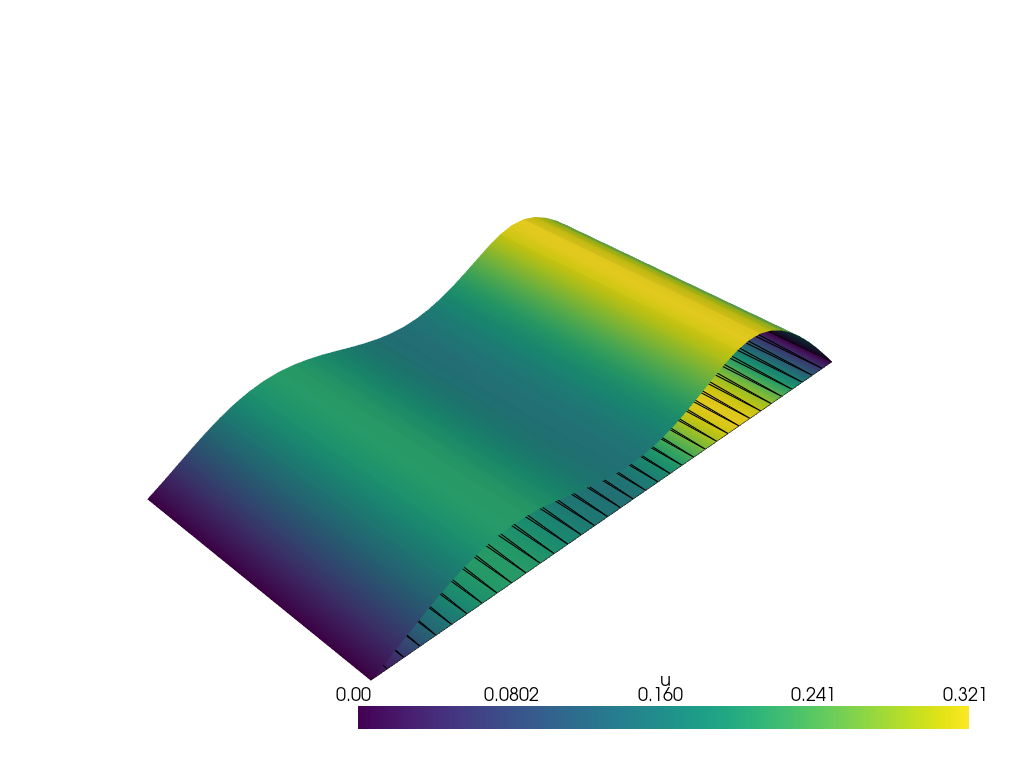

In [ ]:
import pyvista

cells, types, x = plot.vtk_mesh(V)
grid = pyvista.UnstructuredGrid(cells, types, x)
grid.point_data["u"] = uh.x.array.real
grid.set_active_scalars("u")
plotter = pyvista.Plotter()
plotter.add_mesh(grid, show_edges=True)
warped = grid.warp_by_scalar()
plotter.add_mesh(warped)
if pyvista.OFF_SCREEN:
    plotter.screenshot(out_folder / "uh_poisson.png")
else:
    plotter.show()